In [ ]:
import re
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import gc

from bs4 import BeautifulSoup

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score

from tqdm import tqdm
from torch import nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

## Scraping

### Scrape Data

In [ ]:
skipKeywords = ['sumber', 'baca juga', 'advertisement', 'penulis', 'channel whatsapp', 'klik di sini', 'iklan', 'scroll to continue']

Saat scraping, bila langsung mengambil keseluruhan body, maka biasanya iklan akan termasuk pada hasil scraping dan berpotensi mengganggu hasil dari model. Oleh karena itu, scraping akan memperhatikan isi dari berita saja, tidak menghiraukan iklan ataupun hyperlink yang mungkin tercantum pada berita. Keywords diatas adalah beberapa keywords yang berpotensi membawa hyperlink. Maka, akan di skip jika paragraf mengandung kata-kata tersebut.

Untuk scraping dari berbagai website, akan dibuat dalam beragam function. Hal ini disebabkan karena letak artikel dan class yang digunakan pada setiap website berbeda-beda. Oleh karena itu, untuk mempermudah scraping, akan dipisah berdasarkan website yang diambil, yaitu Detik, Liputan6, Kompas, dan Bola.

In [ ]:
def scrapingDetik(link, label):
    headers = {'User-Agent' : 'Mozilla/5.0'}
    response = requests.get(link, headers=headers)

    soup = BeautifulSoup(response.content, 'html.parser')
    articles = soup.find_all('article', limit = 15)

    dataDict = []
    for article in articles:
        link = article.find('a')['href']

        articlePage = requests.get(link, headers=headers)
        articleContent = BeautifulSoup(articlePage.content, 'html.parser')
        articleBody = articleContent.find('div', class_ = 'detail__body-text')

        if articleBody:
            paragraphs = articleBody.find_all('p')

            content = []
            for paragraph in paragraphs:
                text = paragraph.get_text(separator=' ', strip=True)

                if not any(keyword in text.lower() for keyword in skipKeywords):
                    if len(text) > 20:
                        content.append(text)

            fullText = ' '.join(content)

            data = {
                'Teks' : fullText,
                'Media' : 'detik.com',
                'Label' : label
            }

            dataDict.append(data)

    return dataDict

Saat melakukan scraping, akan ada header yang digunakan, hal ini bertujuan agar tidak dianggap sebagai bot, sehingga data dapat diambil. Untuk mendapatkan respond dari website, request akan digunakan. Dengan bantuan API BeautifulSoup, data yang berada dalam tag content akan diambil dari html.parser. Dari content website, akan dicari bagian pada website yang mengandung artikel. Untuk setiap website, akan berbeda-beda, seperti contoh berikut: 
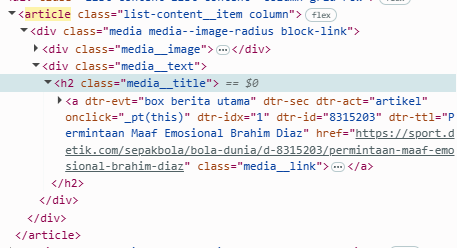

Foto tersebut dilihat dari inspeksi pada website detik. BeautifulSoup akan mencari seluruh tag 'article' dan akan mengambil link pada setiap article. ('a' adalah tag untuk link pada html dan 'href' adalah linknya).

Setelah mendapatkan link artikel, scraper akan mengirim request lagi untuk mengakses isi konten dari article. Kali ini, untuk mengambil data dari berita, maka akan mencari tag 'div' dan data yang diambil adalah data yang memiliki class 'detail__body-text' yang menjadi tempat seluruh text berada. Seperti yang dilihat, terkadang terdapat iklan diantara berita dan dapat mengganggu data, oleh karena itu, hanya data/text berita dalam tag 'p' yang akan diambil dalam sebuah loop. Hasil loop tersebut akan dalam bentuk list, sehingga akan perlu di join terlebih dahulu untuk mendapatkan berita keseluruhan. Hal ini akan dijalankan pada seluruh platform berita yang digunakan. Dimana cara kerja untuk setiap function akan sama, hanya akan terdapat perbedaan pada tag dan nama classnya saja.

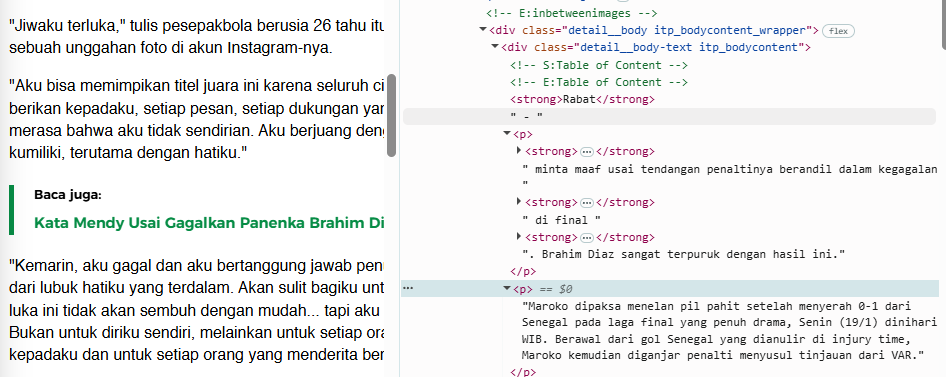

In [ ]:
def scrapingLiputan6(link, label):
    headers = {'User-Agent' : 'Mozilla/5.0'}
    response = requests.get(link, headers=headers)

    soup = BeautifulSoup(response.content, 'html.parser')
    articles = soup.find_all('article', limit = 15)

    dataDict = []
    for article in articles:
        link = article.find('a')['href']

        articlePage = requests.get(link, headers=headers)
        articleContent = BeautifulSoup(articlePage.content, 'html.parser')
        articleBody = articleContent.find('div', class_ = 'article-content-body')

        if articleBody:
            paragraphs = articleBody.find_all('p')

            content = []
            for paragraph in paragraphs:
                text = paragraph.get_text(separator=' ', strip=True)

                if not any(keyword in text.lower() for keyword in skipKeywords):
                    if len(text) > 20:
                        content.append(text)

            fullText = ' '.join(content)

            data = {
                'Teks' : fullText,
                'Media' : 'Liputan 6',
                'Label' : label
            }

            dataDict.append(data)

    return dataDict

In [ ]:
def scrapingKompas(link, label):
    headers = {'User-Agent' : 'Mozilla/5.0'}
    response = requests.get(link, headers=headers)

    soup = BeautifulSoup(response.content, 'html.parser')
    articles = soup.find_all('a', class_='article__link', limit=15)

    dataDict = []
    for article in articles:
        link = article['href']

        articlePage = requests.get(link, headers=headers)
        articleContent = BeautifulSoup(articlePage.content, 'html.parser')

        articleBody = articleContent.find('div', class_ = 'read__content')

        if articleBody:
            paragraphs = articleBody.find_all('p')

            content = []
            for paragraph in paragraphs:
                text = paragraph.get_text(separator=' ', strip=True)

                if not any(keyword in text.lower() for keyword in skipKeywords):
                    if len(text) > 20:
                        content.append(text)

            fullText = ' '.join(content)

            data = {
                'Teks' : fullText,
                'Media' : 'Kompas.com',
                'Label' : label
            }

            dataDict.append(data)

    return dataDict

In [ ]:
def scrapingBola(link, label):
    headers = {'User-Agent' : 'Mozilla/5.0'}
    response = requests.get(link, headers=headers)

    soup = BeautifulSoup(response.content, 'html.parser')
    articles = soup.find_all('article', limit=15)

    dataDict = []
    for article in articles:
        link = article.find('a')['href']

        articlePage = requests.get(link, headers=headers)
        articleContent = BeautifulSoup(articlePage.content, 'html.parser')

        articleBody = articleContent.find('div', class_ = 'article-content-body')

        if articleBody:
            paragraphs = articleBody.find_all('p')

            content = []
            for paragraph in paragraphs:
                text = paragraph.get_text(separator=' ', strip=True)

                if not any(keyword in text.lower() for keyword in skipKeywords):
                    if len(text) > 20:
                        content.append(text)

            fullText = ' '.join(content)

            data = {
                'Teks' : fullText,
                'Media' : 'bola.com',
                'Label' : label
            }

            dataDict.append(data)

    return dataDict

Berikut adalah list yang berisi kumpulan link yang digunakan untuk setiap platform berita. Dibuat dalam list agar dapat dibuat sebagai sebuah loop, sehingga tidak perlu manual.

In [ ]:
dataDetik = [
    {
        'link' : 'https://sport.detik.com/sepakbola/liga-inggris' ,
        'label' : 'Liga Inggris'
    },
    {
        'link' : 'https://sport.detik.com/sepakbola/liga-italia' ,
        'label' : 'Liga Italia'
    },
    {
        'link' : 'https://sport.detik.com/sepakbola/liga-spanyol' ,
        'label' : 'Liga Spanyol'
    },
    {
        'link' : 'https://sport.detik.com/sepakbola/liga-indonesia' ,
        'label' : 'Liga Indonesia'
    },
    {
        'link' : 'https://sport.detik.com/basket' ,
        'label' : 'Non Sepak Bola'
    },
    {
        'link' : 'https://sport.detik.com/raket' ,
        'label' : 'Non Sepak Bola'
    },
    {
        'link' : 'https://sport.detik.com/moto-gp' ,
        'label' : 'Non Sepak Bola'
    }
]

In [ ]:
dataLiputan6 = [
    {
        'link' : 'https://www.liputan6.com/bola/liga-inggris' ,
        'label' : 'Liga Inggris'
    },
    {
        'link' : 'https://www.liputan6.com/bola/liga-italia' ,
        'label' : 'Liga Italia'
    },
    {
        'link' : 'https://www.liputan6.com/bola/liga-spanyol' ,
        'label' : 'Liga Spanyol'
    },
    {
        'link' : 'https://www.liputan6.com/tag/bola-basket' ,
        'label' : 'Non Sepak Bola'
    }
]

In [ ]:
dataKompas = [
    {
        'link' : 'https://bola.kompas.com/liga-inggris' ,
        'label' : 'Liga Inggris'
    },
    {
        'link' : 'https://bola.kompas.com/liga-italia' ,
        'label' : 'Liga Italia'
    },
    {
        'link' : 'https://bola.kompas.com/liga-spanyol' ,
        'label' : 'Liga Spanyol'
    },
    {
        'link' : 'https://www.kompas.com/sports' ,
        'label' : 'Non Sepak Bola'
    }
]

In [ ]:
dataBola = [
    {
        'link' : 'https://bola.com/inggris' ,
        'label' : 'Liga Inggris'
    },
    {
        'link' : 'https://bola.com/indonesia' ,
        'label' : 'Liga Indonesia'
    },
    {
        'link' : 'https://bola.com/spanyol' ,
        'label' : 'Liga Spanyol'
    },
    {
        'link' : 'https://www.bola.com/ragam' ,
        'label' : 'Non Sepak Bola'
    }
]

In [ ]:
data = []

for i in dataDetik:
    data.extend(scrapingDetik(i['link'], i['label']))

for i in dataLiputan6:
    data.extend(scrapingLiputan6(i['link'], i['label']))

for i in dataKompas:
    data.extend(scrapingKompas(i['link'], i['label']))

for i in dataBola:
    data.extend(scrapingBola(i['link'], i['label']))

### Preprocess Scraped Text

Data hasil scrapping akan dibuat dalam sebuah DataFrame

In [ ]:
df = pd.DataFrame(data)
df.head()

,Teks,Media,Label
0,Drawing Piala AFF 2026 tuntas digelar. Pelatih...,detik.com,Liga Inggris
1,Hasil drawing grup Piala AFF 2026 sudah bisa d...,detik.com,Liga Inggris
2,Timnas Mesir disingkirkan Senegal dari persain...,detik.com,Liga Inggris
3,Michael Carrick sudah ditunjuk sebagai manajer...,detik.com,Liga Inggris
4,Arsenal berhasil menumbangkan Chelsea dalam le...,detik.com,Liga Inggris


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Teks    283 non-null    object
 1   Media   283 non-null    object
 2   Label   283 non-null    object
dtypes: object(3)
memory usage: 6.8+ KB


Jumlah data total hasil scrapping ada 283 data.

In [5]:
df['Label'].value_counts()

,count
Label,
Non Sepak Bola,90
Liga Inggris,60
Liga Spanyol,58
Liga Italia,45
Liga Indonesia,30


Untuk persebaran data cukup imbalance, dimana Liga Indonesia memiliki jumlah paling sedikit dan didominasi oleh kategori Non Sepak Bola

In [6]:
dupe = df['Teks'].duplicated()
print(dupe.sum())
df['Teks'][dupe]

39


,Teks
8,Lowongnya posisi manajer tetap di Manchester U...
9,Casemiro memiliki satu syarat agar kontraknya ...
15,Drawing Piala AFF 2026 tuntas digelar. Pelatih...
16,Hasil drawing grup Piala AFF 2026 sudah bisa d...
17,Timnas Mesir disingkirkan Senegal dari persain...
18,Michael Carrick sudah ditunjuk sebagai manajer...
19,Arsenal berhasil menumbangkan Chelsea dalam le...
27,AC Milan membuntuti Inter Milan di klasemen se...
30,Drawing Piala AFF 2026 tuntas digelar. Pelatih...
31,Hasil drawing grup Piala AFF 2026 sudah bisa d...


Dari hasil scrapping, ternyata terdapat 39 data yang duplikat pada teksnya, maka data tersebut akan di drop.

In [7]:
df = df[~dupe].reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Teks    244 non-null    object
 1   Media   244 non-null    object
 2   Label   244 non-null    object
dtypes: object(3)
memory usage: 5.8+ KB


Data yang awalnya berjumlah 283 menjadi 244 data.

In [8]:
df['Teks'].duplicated().sum()

np.int64(0)

Saat di cek kembali, sudah tidak ada data duplikat

In [9]:
df['Label'].value_counts()

,count
Label,
Non Sepak Bola,72
Liga Inggris,58
Liga Spanyol,52
Liga Italia,39
Liga Indonesia,23


Jumlah data setiap label setelah di drop value duplikat tetap didominasi oleh Non Sepak Bola

## a. Text Preprocessing

### Data Splitting

In [10]:
x = df['Teks']
y = df['Label']

y.value_counts()

,count
Label,
Non Sepak Bola,72
Liga Inggris,58
Liga Spanyol,52
Liga Italia,39
Liga Indonesia,23


Data akan displit menjadi x dan y, dimana x adalah variabel independen dan y adalah variabel dependen/target. Variabel x dan y ini akan digunakan untuk metode yang hanya menggunakan 1 stage, yaitu langsung klasifikasi 5 kategori.

In [11]:
x2Stage1 = []
y2Stage1 = []

for i, j in zip(x, y):
    if j == 'Non Sepak Bola':
        x2Stage1.append(i)
        y2Stage1.append(j)
    else:
        x2Stage1.append(i)
        y2Stage1.append('Sepak Bola')

x2Stage1 = pd.Series(x2Stage1)
y2Stage1 = pd.Series(y2Stage1)

y2Stage1.value_counts()

,count
Sepak Bola,172
Non Sepak Bola,72


Sedangkan untuk data yang diatas berfungsi untuk metode kedua yang melewati dua stage, sehingga akan dipersiapkan terlebih dahulu. Data yang ini digunakan untuk tahap pertama dari 2 stage tersebut. Data yang merupakan Sepak Bola (Liga Indonesia, Liga Inggris, dll)  akan masuk ke kategori Sepak Bola dan Non Sepak Bola akan tetap disimpan sebagai Non Sepak Bola.

In [12]:
x2Stage2 = []
y2Stage2 = []

for i, j in zip(x, y):
    if j != 'Non Sepak Bola':
        x2Stage2.append(i)
        y2Stage2.append(j)

x2Stage2 = pd.Series(x2Stage2)
y2Stage2 = pd.Series(y2Stage2)

y2Stage2.value_counts()

,count
Liga Inggris,58
Liga Spanyol,52
Liga Italia,39
Liga Indonesia,23


Sama seperti sebelumnya, code diatas untuk metode kedua yang melewati dua stage, dan ini adalah data untuk tahap kedua. Data yang sudah diklasifikasi sebagai sepak bola akan dipisah menjadi 4 kategori, yaitu Liga Inggris, Spanyol, dll.

### Check Text Length for Max Length

Sebelum data di tokenizer, akan dicari panjang rata-rata dari teks berita yang ada. Hal ini akan berfungsi sebagai penentu panjang token maksimal pada tokenizer. 

120 881


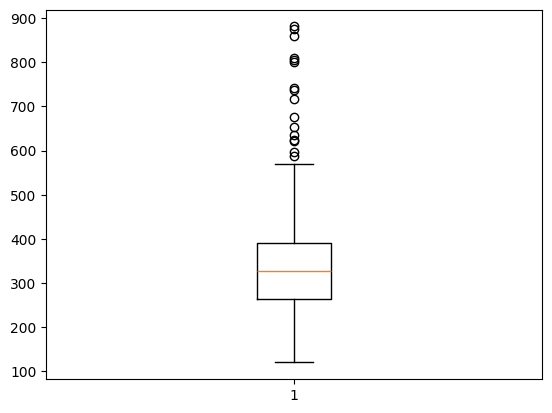

In [13]:
lengthText = [len([word for word in i.split(' ')]) for i in x]
print(min(lengthText), max(lengthText))

plt.boxplot(lengthText)
plt.show()

In [14]:
Q3 = int(np.quantile(lengthText, 0.75))
Q1 = int(np.quantile(lengthText, 0.25))
IQR = Q3-Q1
upperBound = int(np.round(1.5*IQR + Q3))

print('Jumlah data outlier:', len([x for x in lengthText if x > upperBound]))
print('Jumlah data dibawah batas atas:', len([x for x in lengthText if x <= upperBound]))
print('Jumlah data diatas quantile 3:', len([x for x in lengthText if x > Q3]))
print('Batas Atas:', upperBound)
print('Quantile 3:', Q3)

Jumlah data outlier: 16
Jumlah data dibawah batas atas: 228
Jumlah data diatas quantile 3: 60
Batas Atas: 579
Quantile 3: 390


Dari boxplot, diperoleh hasil bahwa rata-rata dan median data berada pada range 100 hingga hampir  600. Akan tetapi,  terdapat 16 data yang merupakan outlier/berada diatas abtas atas. Sedangkan, untuk data yang berada diatas Quantile ke 3 ada 60, dimana data tersebut cukup banyak jika kita bandingkan dengan data yang hanya berjumlah 244 (1:4). Tetapi karena batasan dari model yang digunakan, max_length untuk token hanya 512 dan tidak bisa lebih. Maka, max_length yang akan digunakan adalah 512, dimana seharusnya, tidak akan terlalu banyak data yang terbuang saat maximal jumlah token di set sebagai 512.

### Cleaning

In [15]:
def cleanText(content):
    text = content.casefold()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

Untuk proses text cleaning, karena akan menggunakan LLM, maka data tidak akan dibersihkan secara berlebihan. Tanda baca tidak akan dibuang, hanya akan ada tag html yang dibuang, karena terkadang dalam berita ada menyangkutkan link redirect. Selain itu, tag user (misalkan username instagram, reply twitter/x, dll) dan hashtag juga akan dibuang. Hal ini hanya digunakan untuk berjaga-jaga bila terdapat pada data. Lalu, spasi berlebih juga akan dibuang. 

### Manual Labeling

In [16]:
labelModel1 = {
    'Non Sepak Bola' : 0,
    'Liga Inggris' : 1,
    'Liga Italia' : 2,
    'Liga Spanyol' : 3,
    'Liga Indonesia' : 4
}

labelModel2Stage1 = {
    'Non Sepak Bola' : 0,
    'Sepak Bola' : 1
}

labelModel2Stage2 = {
    'Liga Inggris' : 0,
    'Liga Italia' : 1,
    'Liga Spanyol' : 2,
    'Liga Indonesia' : 3
}

Untuk variabel target, akan di label secara manual seperti diatas.

### Tokenization

Untuk model yang digunakan ada 2, yaitu RoBERTa dan BERT. Keduanya diambil dari website huggingface.

In [17]:
bertTokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p2')
robertaTokenizer = AutoTokenizer.from_pretrained('cahya/roberta-base-indonesian-522M')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

In [18]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, xData, yData, tokenizer, labelUsed):
        self.x = xData.tolist()
        self.y = yData.tolist()
        self.labels = [labelUsed[label] for label in self.y]
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        x = self.x[index]
        label = self.labels[index]

        encode = self.tokenizer(x,
                                padding='max_length',
                                max_length=512,
                                truncation=True,
                                return_tensors='pt'
                                )

        return {
            'inputIds' : encode['input_ids'].squeeze(0),
            'attentionMask' : encode['attention_mask'].squeeze(0),
            'labels' : torch.tensor(label)
        }

Untuk pembuatan dataset dan tokenizer akan dijalankan dalam class Dataset diatas. Saat class dipanggil, akan ada 4 data yang diberikan yaitu x, y, tokenizer (BERT/RoBERTa) yang telah diload dan label yang akan digunakan. Setiap data tersebut akan  dimasukkan ke dalam class dan dibuat sebagai bagian dari class (self), sehingga data dapat dipanggil dari function manapun di dalam class Dataset ini. 

Pada class ini, ada 2 function: 
- len untuk mengembalikan jumlah label
- getitem untuk melakukan tokenizing dan mengembalikan value berupa input_ids, attention_mask, dan labels. 

Kedua input-ids dan attention_mask harus berdimensi 1, sehingga akan disqueeze. Attention_mask sendiri berfungsi sebagai identifier apakah sebuah data termasuk data atau hanyalah padding. Label akan dikembalikan dalam bentuk yang diterima oleh PyTorch.

In [19]:
xTrain, xTemp, yTrain, yTemp = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
xVal, xTest, yVal, yTest = train_test_split(xTemp, yTemp, test_size=0.5, random_state=42, stratify=yTemp)

xTrain2Stage1, xTemp2Stage1, yTrain2Stage1, yTemp2Stage1 = train_test_split(x2Stage1, y2Stage1, test_size=0.2, random_state=42, stratify=y2Stage1)
xVal2Stage1, xTest2Stage1, yVal2Stage1, yTest2Stage1 = train_test_split(xTemp2Stage1, yTemp2Stage1, test_size=0.5, random_state=42, stratify=yTemp2Stage1)

xTrain2Stage2, xTemp2Stage2, yTrain2Stage2, yTemp2Stage2 = train_test_split(x2Stage2, y2Stage2, test_size=0.2, random_state=42, stratify=y2Stage2)
xVal2Stage2, xTest2Stage2, yVal2Stage2, yTest2Stage2 = train_test_split(xTemp2Stage2, yTemp2Stage2, test_size=0.5, random_state=42, stratify=yTemp2Stage2)

Setiap data akan dibuat menjadi 80% Train, 10% Val, dan 10% Test

In [20]:
xTrain = xTrain.apply(cleanText)
xTest = xTest.apply(cleanText)
xVal = xVal.apply(cleanText)

xTrain2Stage1 = xTrain2Stage1.apply(cleanText)
xTest2Stage1 = xTest2Stage1.apply(cleanText)
xVal2Stage1 = xVal2Stage1.apply(cleanText)

xTrain2Stage2 = xTrain2Stage2.apply(cleanText)
xTest2Stage2 = xTest2Stage2.apply(cleanText)
xVal2Stage2 = xVal2Stage2.apply(cleanText)

Data akan melalui proses cleaning sebelum lanjut ke proses tokenizing

In [21]:
xTrain1Bert = Dataset(xTrain, yTrain, bertTokenizer, labelModel1)
xTest1Bert = Dataset(xTest, yTest, bertTokenizer, labelModel1)
xVal1Bert = Dataset(xVal, yVal, bertTokenizer, labelModel1)

xTrain1Roberta = Dataset(xTrain, yTrain, robertaTokenizer, labelModel1)
xTest1Roberta = Dataset(xTest, yTest, robertaTokenizer, labelModel1)
xVal1Roberta = Dataset(xVal, yVal, robertaTokenizer, labelModel1)

In [22]:
xTrain21Bert = Dataset(xTrain2Stage1, yTrain2Stage1, bertTokenizer, labelModel2Stage1)
xTest21Bert = Dataset(xTest2Stage1, yTest2Stage1, bertTokenizer, labelModel2Stage1)
xVal21Bert = Dataset(xVal2Stage1, yVal2Stage1, bertTokenizer, labelModel2Stage1)

xTrain21Roberta = Dataset(xTrain2Stage1, yTrain2Stage1, robertaTokenizer, labelModel2Stage1)
xTest21Roberta = Dataset(xTest2Stage1, yTest2Stage1, robertaTokenizer, labelModel2Stage1)
xVal21Roberta = Dataset(xVal2Stage1, yVal2Stage1, robertaTokenizer, labelModel2Stage1)

In [23]:
xTrain22Bert = Dataset(xTrain2Stage2, yTrain2Stage2, bertTokenizer, labelModel2Stage2)
xTest22Bert = Dataset(xTest2Stage2, yTest2Stage2, bertTokenizer, labelModel2Stage2)
xVal22Bert = Dataset(xVal2Stage2, yVal2Stage2, bertTokenizer, labelModel2Stage2)

xTrain22Roberta = Dataset(xTrain2Stage2, yTrain2Stage2, robertaTokenizer, labelModel2Stage2)
xTest22Roberta = Dataset(xTest2Stage2, yTest2Stage2, robertaTokenizer, labelModel2Stage2)
xVal22Roberta = Dataset(xVal2Stage2, yVal2Stage2, robertaTokenizer, labelModel2Stage2)

Code diatas akan digunakan untuk membuat dataset pada setiap model, yaitu model dengan arsitektur 1 stage (Klasifikasi 5 kategori langsung) dan model kedua yaitu dengan arsitektur 2 stage (Klasifikasi 2 kategori, lalu klasifikasi 4 kategori)

In [24]:
print(len(xTrain1Bert), len(xTrain1Roberta))
print(len(xTest1Bert), len(xTest1Roberta))
print(len(xVal1Bert), len(xVal1Roberta))

195 195
25 25
24 24


In [25]:
print(len(xTrain21Bert), len(xTrain21Roberta))
print(len(xTest21Bert), len(xTest21Roberta))
print(len(xVal21Bert), len(xVal21Roberta))

195 195
25 25
24 24


In [26]:
print(len(xTrain22Bert), len(xTrain22Roberta))
print(len(xTest22Bert), len(xTest22Roberta))
print(len(xVal22Bert), len(xVal22Roberta))

137 137
18 18
17 17


Dapat dilihat bahwa jumlah data untuk setiap stage sudah sesuai. Data pada xTrain22 lebih sedikit dibandingkan xTrain21 atau xTrain1 karena hanya memiliki data untuk kategori SepakBola, sedangkan untuk yang Non Sepak Bola tidak termasuk

## b. Modelling

In [27]:
result = {}
testResult = {}

Data hasil training akan disimpan dalam result dan testResult

In [28]:
def trainOrVal(input, model, device, lossCriterion):
    label = input['labels'].to(device)
    mask = input['attentionMask'].to(device)
    inputId = input['inputIds'].to(device)

    output = model(inputId, mask)
    logits = output.logits

    batchLoss = lossCriterion(logits, label.long())

    preds = logits.argmax(dim=1)

    return preds, label, batchLoss

Function trainOrVal berfungsi untuk menjalankan training pada model. Jadi, data akan dipindahkan ke device yang telah ditentukan. Lalu, model akan ditrain dengan input_ids dan attention_mask yang ada. Hasil dari model akan berupa data mentah, sehingga hasil harus diambil dari logits. Loss akan  dihitung dengan criterion yang digunakan, yaitu CrossEntropyLoss karena klasifikasi multi-kategori.

Function tersebut akan mengembalikan prediksi, label, dan loss dari hasil training.

In [ ]:
def trainModel(name, model, train, val, batchSize=16, learningRate=2e-5, epochs=10, showResult=True):
    trainData = torch.utils.data.DataLoader(train, batch_size=batchSize, shuffle=True)
    valData = torch.utils.data.DataLoader(val, batch_size=batchSize)

    cudaAvail = torch.cuda.is_available()
    device = torch.device('cuda' if cudaAvail else 'cpu')

    lossCriterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=learningRate)

    bestValF1 = 0
    bestTrainF1 = 0
    bestState = None
    bestResult = None

    if cudaAvail:
        model = model.cuda()
        lossCriterion = lossCriterion.cuda()

    for epoch in range(epochs):
        model.train()
        totalAccTrain = 0
        totalLossTrain = 0

        trainPreds = []
        trainLabels = []

        for trainInput in tqdm(trainData):
            preds, trainLabel, batchLoss = trainOrVal(trainInput, model, device, lossCriterion)

            acc = (preds == trainLabel).sum().item()
            totalAccTrain += acc
            totalLossTrain += batchLoss.item()

            trainPreds.extend(preds.cpu().numpy())
            trainLabels.extend(trainLabel.cpu().numpy())

            model.zero_grad()
            batchLoss.backward()
            optimizer.step()

        model.eval()
        totalAccVal = 0
        totalLossVal = 0

        valPreds = []
        valLabels = []

        with torch.no_grad():
            for valInput in valData:
                preds, valLabel, batchLoss = trainOrVal(valInput, model, device, lossCriterion)

                acc = (preds == valLabel).sum().item()
                totalAccVal += acc
                totalLossVal += batchLoss.item()

                valPreds.extend(preds.cpu().numpy())
                valLabels.extend(valLabel.cpu().numpy())

        f1Train = round(f1_score(trainLabels, trainPreds, average='macro'), 3)
        f1Val = round(f1_score(valLabels, valPreds, average='macro'), 3)
        recallTrain = round(recall_score(trainLabels, trainPreds, average='macro'), 3)
        recallVal = round(recall_score(valLabels, valPreds, average='macro'), 3)
        precisionTrain = round(precision_score(trainLabels, trainPreds, average='macro'), 3)
        precisionVal = round(precision_score(valLabels, valPreds, average='macro'), 3)

        avgAccTrain = round(totalAccTrain/len(train), 3)
        avgLossTrain = round(totalLossTrain/len(trainData), 3)
        avgAccVal = round(totalAccVal/len(val), 3)
        avgLossVal = round(totalLossVal/len(valData), 3)


        if showResult:
            print(f'Epochs: {epoch+1}')
            print(f' | Train F1: {f1Train} \n | Train Loss: {avgLossTrain} \n | Train Accuracy: {avgAccTrain}')
            print(f' | Val F1: {f1Val} \n | Val Loss: {avgLossVal} \n | Val Accuracy: {avgAccVal} \n')

        if f1Val >= bestValF1:
            # print('updated value')
            if f1Train > bestTrainF1:
              bestValF1 = f1Val
              bestTrainF1 = f1Train
              bestState = model.state_dict().copy()
              bestResult = {
                  'Train F1-Score' : f1Train,
                  'Train Accuracy' : avgAccTrain,
                  'Train Loss' : avgLossTrain,
                  'Train Recall' : recallTrain,
                  'Train Precision' : precisionTrain,
                  'Val F1-Score' : f1Val,
                  'Val Accuracy' : avgAccVal,
                  'Val Loss' : avgLossVal,
                  'Val Recall' : recallVal,
                  'Val Precision' : precisionVal,
                  'Parameter' : {
                      'Batch Size' : batchSize,
                      'Learning Rate' : learningRate,
                      'Epochs' : epochs
                  }
            }

    if showResult:
        result[name] = bestResult

    if bestState is not None:
        model.load_state_dict(bestState)
    model.cpu()

    if cudaAvail:
        torch.cuda.empty_cache()
    gc.collect()

    return bestValF1, bestTrainF1, model, bestResult

Data akan ditrain dalam beberapa epoch, dimana dalam setiap epoch akan dibagi menjadi beberapa batch. Function trainModel digunakan untuk training dan validasi model sekaligus. Pada setiap epoch, model akan ditrain, akurasi dan lossnya akan dihitung juga per batchnya.

Setelah proses training selesai, model akan masuk ke tahap validasi, yaitu saat torch.no_grad() agar tidak ada nilai gradient yang diupdate lagi. 

Setelah validasi dilakukan, akan dihitung F1-Score, Accuracy, Loss, Precision, dan Recall scorenya dan disimpan dalam result.

In [30]:
def testModel(name, model, test, labelModel, batchSize=16):
    data = torch.utils.data.DataLoader(test, batch_size=batchSize)

    cudaAvail = torch.cuda.is_available()
    device = torch.device('cuda' if cudaAvail else 'cpu')

    if cudaAvail:
        model = model.cuda()

    totalAcc = 0
    testPreds = []
    testLabels = []

    with torch.no_grad():
        for input in data:
            label = input['labels'].to(device)
            mask = input['attentionMask'].to(device)
            inputId = input['inputIds'].to(device)

            output = model(inputId, mask)
            logits = output.logits

            preds = logits.argmax(dim=1)
            accuracy = (preds == label).sum().item()
            totalAcc += accuracy

            testPreds.extend(preds.cpu().numpy())
            testLabels.extend(label.cpu().numpy())

    testAcc = round(totalAcc/len(test), 3)
    testF1 = round(f1_score(testLabels, testPreds, average='macro'), 3)
    testPrecision = round(precision_score(testLabels, testPreds, average='macro'), 3)
    testRecall = round(recall_score(testLabels, testPreds, average='macro'), 3)

    print(
        f'| Test Accuracy: {testAcc} \n| Test F1: {testF1}'
    )

    testResult[name] = {
        'Test F1-Score' : testF1,
        'Test Accuracy' : testAcc,
        'Test Recall' : testRecall,
        'Test Precision' : testPrecision
        }

    targetNames = [k for k, value in sorted(labelModel.items(), key=lambda item: item[1])]
    print(classification_report(testLabels, testPreds, target_names=targetNames, zero_division=0))

    cm = confusion_matrix(testLabels, testPreds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelModel.keys())
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.xticks(rotation=45)
    plt.show()

Testing akan melewati proses yang hampir sama dengan validasi, yaitu tidak akan mengupdate nilai gradient dari model. Hasil testing akan disimpan dalam testResult, serta akan dimunculkan classification report dan confusion matrix dari hasil testing

### 1) 1 Stage: Klasifikasi 5 Kategori

#### a) Baseline

Untuk 1 Stage, akan dilakukan baseline dan hyperparameter untuk mencari parameter terbaik. Model yang digunakan sama seperti tokenizer yaitu BERT dan RoBERTa

In [ ]:
bertModel = AutoModelForSequenceClassification.from_pretrained('indobenchmark/indobert-base-p2', num_labels=5)
robertaModel = AutoModelForSequenceClassification.from_pretrained('cahya/roberta-base-indonesian-522M', num_labels=5)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cahya/roberta-base-indonesian-522M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
for param in bertModel.base_model.parameters():
    param.requires_grad = False

for param in robertaModel.base_model.parameters():
    param.requires_grad = False

Karena model baseline, maka kepala dari kedua model akan difreeze, sehingga tidak akan menghitung Gradien. Jadi hanya perlu ditambahkan sebuah layer untuk klasifikasi data yang ada.

##### Bert

In [ ]:
bestValF1Bert1Stage, bestTrainF1Bert1Stage, bestModelBert1Stage, bestResultBert1Stage = trainModel('Bert 1 Stage', bertModel, xTrain1Bert, xVal1Bert)


  0%|          | 0/13 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/507M [00:00<?, ?B/s]

100%|██████████| 13/13 [00:06<00:00,  1.91it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epochs: 1
 | Train F1: 0.098 
 | Train Loss: 1.649 
 | Train Accuracy: 0.185
 | Val F1: 0.071 
 | Val Loss: 1.63 
 | Val Accuracy: 0.208 



100%|██████████| 13/13 [00:05<00:00,  2.38it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Epochs: 8
 | Train F1: 0.202 
 | Train Loss: 1.55 
 | Train Accuracy: 0.277
 | Val F1: 0.32 
 | Val Loss: 1.527 
 | Val Accuracy: 0.458 



100%|██████████| 13/13 [00:05<00:00,  2.35it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epochs: 9
 | Train F1: 0.191 
 | Train Loss: 1.559 
 | Train Accuracy: 0.256
 | Val F1: 0.342 
 | Val Loss: 1.517 
 | Val Accuracy: 0.5 



100%|██████████| 13/13 [00:05<00:00,  2.27it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epochs: 10
 | Train F1: 0.216 
 | Train Loss: 1.551 
 | Train Accuracy: 0.308
 | Val F1: 0.315 
 | Val Loss: 1.513 
 | Val Accuracy: 0.458 



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


| Test Accuracy: 0.24 
| Test F1: 0.147
                precision    recall  f1-score   support

Non Sepak Bola       0.40      0.29      0.33         7
  Liga Inggris       0.29      0.67      0.40         6
   Liga Italia       0.00      0.00      0.00         4
  Liga Spanyol       0.00      0.00      0.00         5
Liga Indonesia       0.00      0.00      0.00         3

      accuracy                           0.24        25
     macro avg       0.14      0.19      0.15        25
  weighted avg       0.18      0.24      0.19        25



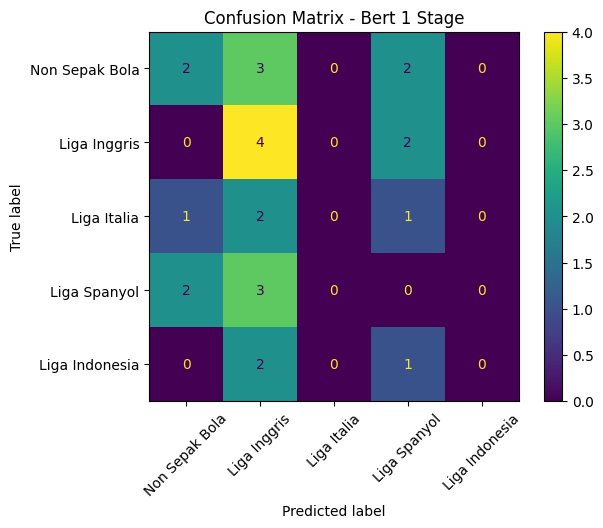

In [ ]:
testModel('Bert 1 Stage', bertModel, xTest1Bert,labelModel1)

Hasil dari model baseline menunjukkan bahwa performa dari model masih sangat buruk, yaitu hanya 0.24 akurasi dengan F1-Score 0.15. Diperlukan finetuning dengan parameter tertentu agar diperoleh hasil yang lebih baik lagi.

##### Roberta

In [ ]:
bestValF1Roberta1Stage, bestTrainF1Roberta1Stage, bestModelRoberta1Stage, bestResultRoberta1Stage = trainModel('Roberta 1 Stage', robertaModel, xTrain1Roberta, xVal1Roberta)


100%|██████████| 13/13 [00:05<00:00,  2.30it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epochs: 1
 | Train F1: 0.091 
 | Train Loss: 1.599 
 | Train Accuracy: 0.272
 | Val F1: 0.09 
 | Val Loss: 1.526 
 | Val Accuracy: 0.292 



100%|██████████| 13/13 [00:05<00:00,  2.26it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epochs: 2
 | Train F1: 0.167 
 | Train Loss: 1.506 
 | Train Accuracy: 0.328
 | Val F1: 0.209 
 | Val Loss: 1.49 
 | Val Accuracy: 0.375 



100%|██████████| 13/13 [00:05<00:00,  2.28it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


...

Epochs: 8
 | Train F1: 0.434 
 | Train Loss: 1.326 
 | Train Accuracy: 0.595
 | Val F1: 0.337 
 | Val Loss: 1.312 
 | Val Accuracy: 0.542 



100%|██████████| 13/13 [00:05<00:00,  2.18it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epochs: 9
 | Train F1: 0.496 
 | Train Loss: 1.313 
 | Train Accuracy: 0.646
 | Val F1: 0.493 
 | Val Loss: 1.291 
 | Val Accuracy: 0.625 



100%|██████████| 13/13 [00:06<00:00,  2.16it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epochs: 10
 | Train F1: 0.528 
 | Train Loss: 1.258 
 | Train Accuracy: 0.667
 | Val F1: 0.419 
 | Val Loss: 1.26 
 | Val Accuracy: 0.583 



| Test Accuracy: 0.48 
| Test F1: 0.302
                precision    recall  f1-score   support

Non Sepak Bola       0.55      0.86      0.67         7
  Liga Inggris       0.42      0.83      0.56         6
   Liga Italia       0.00      0.00      0.00         4
  Liga Spanyol       0.50      0.20      0.29         5
Liga Indonesia       0.00      0.00      0.00         3

      accuracy                           0.48        25
     macro avg       0.29      0.38      0.30        25
  weighted avg       0.35      0.48      0.38        25



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


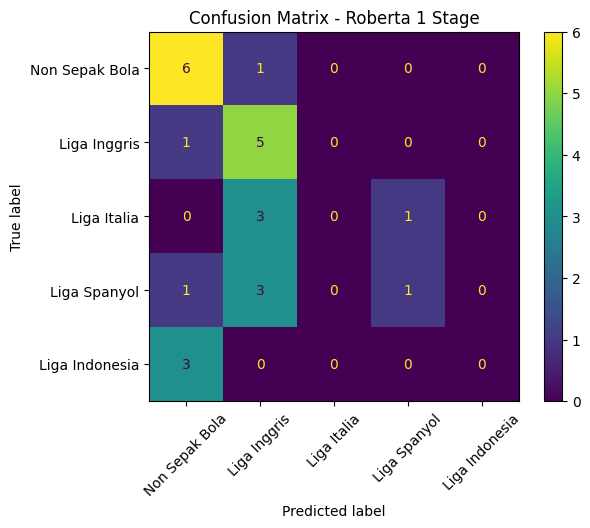

In [ ]:
testModel('Roberta 1 Stage', robertaModel, xTest1Roberta, labelModel1)

Sama seperti model BERT, model RoBERTa ini juga memiliki performa yang buruk untuk baselinenya, hanya 0.48 akurasi dan 0.3 F1-Score. Hal ini menunjukkan kedua model sangat memperlukan finetuning agar ditemukan model yang memiliki performa baik.

#### b) Hyperparameter Finetune

Pada data ini akan dilakukan 8 kali training dengan berbagai parameter finetuning untuk setiap modelnya. 

In [ ]:
parameter = {
    'learningRate' : [2e-5, 4e-5],
    'epochs' : [10, 20],
    'batchSize' : [8, 16]
}

In [ ]:
def hyperparameterFinetuning(name, pretrained, train, val, test, labelModel):
    bestOverallValF1 = 0
    bestOverallTrainF1 = 0
    bestOverallResult = {}
    bestOverallModel = None

    for learningRate in parameter['learningRate']:
        for batchSize in parameter['batchSize']:
            for epoch in parameter['epochs']:
                config = AutoConfig.from_pretrained(pretrained,
                num_labels=5,
                hidden_dropout_prob=0.2)

                model = AutoModelForSequenceClassification.from_pretrained(pretrained, config=config)

                valF1, trainF1, bestModel, bestResult = trainModel(name, model, train, val, batchSize, learningRate, epoch, False)

                if (valF1 >= bestOverallValF1):
                    if (trainF1 > bestOverallTrainF1):
                    # print('updated hyperparam value')
                      bestOverallValF1 = valF1
                      bestOverallTrainF1 = trainF1
                      bestOverallResult = bestResult
                      bestOverallModel = bestModel

                for i in bestResult:
                    if i == 'Parameter':
                        for j in bestResult[i]:
                            print(f'| {j}: {bestResult[i][j]}')
                    else:
                        print(f'| {i}: {bestResult[i]}')

                print('| Dropout: 0.2\n')

    result[name] = bestOverallResult

    if bestOverallModel:
       testModel(name, bestOverallModel, test, labelModel)

    print('Best Validation F1-Score:', bestOverallValF1)
    print('Best Parameter:', bestOverallResult['Parameter'])

    return bestOverallValF1, bestOverallModel, bestOverallResult

Secara garis besar, cara kerja finetuning ini akan sama seperti training biasanya. Data hanya akan diupdate jika F1-Score Validation lebih baik dibandingkan epoch sebelumnya. Karena function untuk training telah dibuat dan disesuaikan dengan finetuning, maka tidak banyak perubahan yang akan dilakukan.

##### Bert

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 25/25 [00:17<00:00,  1.39it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 25/25 [00:1

| Train F1-Score: 0.956
| Train Accuracy: 0.964
| Train Loss: 0.166
| Train Recall: 0.951
| Train Precision: 0.961
| Val F1-Score: 0.92
| Val Accuracy: 0.958
| Val Loss: 0.112
| Val Recall: 0.975
| Val Precision: 0.9
| Batch Size: 8
| Learning Rate: 2e-05
| Epochs: 10
| Dropout: 0.2



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 25/25 [00:17<00:00,  1.39it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 25/25 [00:1

| Train F1-Score: 0.978
| Train Accuracy: 0.985
| Train Loss: 0.093
| Train Recall: 0.976
| Train Precision: 0.98
| Val F1-Score: 1.0
| Val Accuracy: 1.0
| Val Loss: 0.086
| Val Recall: 1.0
| Val Precision: 1.0
| Batch Size: 8
| Learning Rate: 2e-05
| Epochs: 20
| Dropout: 0.2



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 13/13 [00:17<00:00,  1.36s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 13/13 [00:17<00:00,  1.36s/it]


...

| Train F1-Score: 0.914
| Train Accuracy: 0.933
| Train Loss: 0.231
| Train Recall: 0.917
| Train Precision: 0.91
| Val F1-Score: 0.96
| Val Accuracy: 0.958
| Val Loss: 0.133
| Val Recall: 0.96
| Val Precision: 0.967
| Batch Size: 8
| Learning Rate: 4e-05
| Epochs: 20
| Dropout: 0.2



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 13/13 [00:17<00:00,  1.36s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 13/13 [00:1

| Train F1-Score: 0.985
| Train Accuracy: 0.99
| Train Loss: 0.06
| Train Recall: 0.98
| Train Precision: 0.991
| Val F1-Score: 1.0
| Val Accuracy: 1.0
| Val Loss: 0.068
| Val Recall: 1.0
| Val Precision: 1.0
| Batch Size: 16
| Learning Rate: 4e-05
| Epochs: 10
| Dropout: 0.2



Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 13/13 [00:17<00:00,  1.36s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 13/13 [00:1

| Train F1-Score: 0.977
| Train Accuracy: 0.985
| Train Loss: 0.086
| Train Recall: 0.975
| Train Precision: 0.98
| Val F1-Score: 0.96
| Val Accuracy: 0.958
| Val Loss: 0.074
| Val Recall: 0.96
| Val Precision: 0.967
| Batch Size: 16
| Learning Rate: 4e-05
| Epochs: 20
| Dropout: 0.2

| Test Accuracy: 0.96 
| Test F1: 0.96
                precision    recall  f1-score   support

Non Sepak Bola       1.00      1.00      1.00         7
  Liga Inggris       1.00      0.83      0.91         6
   Liga Italia       0.80      1.00      0.89         4
  Liga Spanyol       1.00      1.00      1.00         5
Liga Indonesia       1.00      1.00      1.00         3

      accuracy                           0.96        25
     macro avg       0.96      0.97      0.96        25
  weighted avg       0.97      0.96      0.96        25



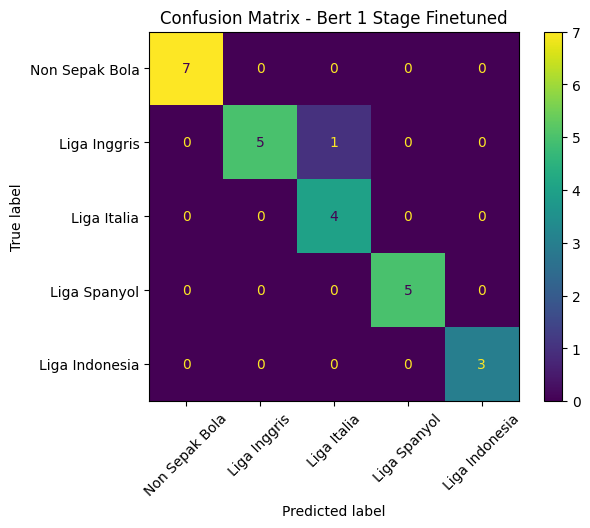

Best Validation F1-Score: 1.0
Best Parameter: {'Batch Size': 16, 'Learning Rate': 4e-05, 'Epochs': 10}


In [ ]:
bert1StageFinetunedF1, bert1StageFinetunedBestModel, bert1StageBestFinetunedResult = hyperparameterFinetuning('Bert 1 Stage Finetuned', 'indobenchmark/indobert-base-p2', xTrain1Bert, xVal1Bert, xTest1Bert, labelModel1)

Dari hasil finetuning, ditemukan bahwa parameter terbaik untuk model BERT adalah\
'Batch Size': 16, 'Learning Rate': 4e-05, 'Epochs': 10

Hasil finetuning juga menunjukkan bahwa model telah memiliki performa yang jauh lebih baik. Hal ini dapat disebabkan oleh perbedaan learning rate yang lebih besar, selain itu Header/Kepala layer dari BERT juga tidak dibekukan. Tetapi karena tidak dibekukan, akibatnya ada kemungkinan overfit karena jumlah data kecil.

##### Roberta

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cahya/roberta-base-indonesian-522M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 25/25 [00:18<00:00,  1.35it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 25/25 [00:18<00:00,  1.35it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to

| Train F1-Score: 1.0
| Train Accuracy: 1.0
| Train Loss: 0.037
| Train Recall: 1.0
| Train Precision: 1.0
| Val F1-Score: 1.0
| Val Accuracy: 1.0
| Val Loss: 0.087
| Val Recall: 1.0
| Val Precision: 1.0
| Batch Size: 8
| Learning Rate: 2e-05
| Epochs: 10
| Dropout: 0.2



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cahya/roberta-base-indonesian-522M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 25/25 [00:18<00:00,  1.38it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

| Train F1-Score: 0.98
| Train Accuracy: 0.985
| Train Loss: 0.054
| Train Recall: 0.976
| Train Precision: 0.985
| Val F1-Score: 1.0
| Val Accuracy: 1.0
| Val Loss: 0.07
| Val Recall: 1.0
| Val Precision: 1.0
| Batch Size: 8
| Learning Rate: 2e-05
| Epochs: 20
| Dropout: 0.2



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cahya/roberta-base-indonesian-522M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 13/13 [00:17<00:00,  1.37s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 13/13 [00:17<00:00,  1.37s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to

...

| Train F1-Score: 1.0
| Train Accuracy: 1.0
| Train Loss: 0.013
| Train Recall: 1.0
| Train Precision: 1.0
| Val F1-Score: 1.0
| Val Accuracy: 1.0
| Val Loss: 0.024
| Val Recall: 1.0
| Val Precision: 1.0
| Batch Size: 8
| Learning Rate: 4e-05
| Epochs: 20
| Dropout: 0.2



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cahya/roberta-base-indonesian-522M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 13/13 [00:17<00:00,  1.37s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

| Train F1-Score: 1.0
| Train Accuracy: 1.0
| Train Loss: 0.018
| Train Recall: 1.0
| Train Precision: 1.0
| Val F1-Score: 1.0
| Val Accuracy: 1.0
| Val Loss: 0.08
| Val Recall: 1.0
| Val Precision: 1.0
| Batch Size: 16
| Learning Rate: 4e-05
| Epochs: 10
| Dropout: 0.2



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cahya/roberta-base-indonesian-522M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 13/13 [00:17<00:00,  1.37s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
100%|██████████| 13/13 [00:17<00:00,  1.37s/it]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to

| Train F1-Score: 0.796
| Train Accuracy: 0.841
| Train Loss: 0.508
| Train Recall: 0.867
| Train Precision: 0.775
| Val F1-Score: 0.92
| Val Accuracy: 0.958
| Val Loss: 0.325
| Val Recall: 0.975
| Val Precision: 0.9
| Batch Size: 16
| Learning Rate: 4e-05
| Epochs: 20
| Dropout: 0.2

| Test Accuracy: 0.92 
| Test F1: 0.906
                precision    recall  f1-score   support

Non Sepak Bola       0.88      1.00      0.93         7
  Liga Inggris       1.00      0.83      0.91         6
   Liga Italia       0.80      1.00      0.89         4
  Liga Spanyol       1.00      1.00      1.00         5
Liga Indonesia       1.00      0.67      0.80         3

      accuracy                           0.92        25
     macro avg       0.93      0.90      0.91        25
  weighted avg       0.93      0.92      0.92        25



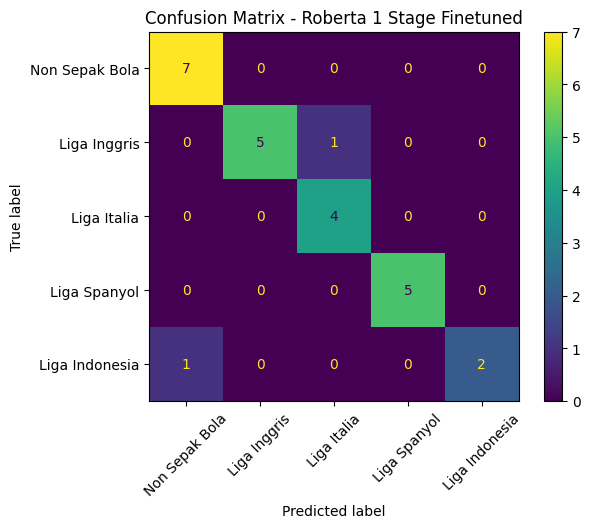

Best Validation F1-Score: 1.0
Best Parameter: {'Batch Size': 8, 'Learning Rate': 2e-05, 'Epochs': 10}


In [ ]:
roberta1StageFinetunedF1, roberta1StageFinetunedBestModel, roberta1StageBestFinetunedResult = hyperparameterFinetuning('Roberta 1 Stage Finetuned', 'cahya/roberta-base-indonesian-522M', xTrain1Roberta, xVal1Roberta, xTest1Roberta, labelModel1)

Sama seperti model BERT, finetuning menaikkan performa dari model RoBERTa. Parameter terbaiknya: \
'Batch Size': 8, 'Learning Rate': 2e-05, 'Epochs': 10

Karena layer head/kepala juga tidak difreeze, maka hasil yang bagus ini dapat disebabkan oleh overfitting ataupun memang karena performanya yang naik, karena secara metrics penilaian (akurasi, f1-score, precision, dan recall) cukup stabil untuk ketiga train, val, dan test.

####

### 2) 2 Stage: Klasifikasi 2 Kategori, lalu 4 Kategori lainnya.

Selanjutnya untuk model kedua, yaitu klasifikasi 2 kategori (SepakBola/Non Sepak Bola) dan klasifikasi lanjutan untuk 4 kategori sepak bola akan dijalankan pada function steps2Stage berikut.

In [ ]:
def steps2Stage(name, pretrained, trainPart1, valPart1, trainPart2, valPart2, testData, batchSize, learningRate, epochs):
    modelPart1 = AutoModelForSequenceClassification.from_pretrained(pretrained, num_labels=2)
    cudaAvail = torch.cuda.is_available()
    device = torch.device('cuda' if cudaAvail else 'cpu')

    if cudaAvail:
        modelPart1 = modelPart1.cuda()

    modelPart1.to(device)
    valF1Part1, trainF1Part1, bestModelPart1, bestResultPart1 = trainModel(name+' Part 1', modelPart1, trainPart1, valPart1, batchSize, learningRate, epochs)
    bestModelPart1.to(device)

    modelPart2 = AutoModelForSequenceClassification.from_pretrained(pretrained, num_labels=4)
    cudaAvail = torch.cuda.is_available()
    device = torch.device('cuda' if cudaAvail else 'cpu')

    if cudaAvail:
        modelPart2 = modelPart2.cuda()

    modelPart2.to(device)
    valF1Part2, trainF1Part2, bestModelPart2, bestResultPart2 = trainModel(name+' Part 2', modelPart2, trainPart2, valPart2, batchSize, learningRate, epochs)
    bestModelPart2.to(device)

    data = torch.utils.data.DataLoader(testData, batch_size=1)

    predictionsPart1 = []
    predictionsPart2 = []
    labelsPart1 = []
    labelsPart2 = []

    with torch.no_grad():
        for input in tqdm(data):
            label = input['labels'].item()
            mask = input['attentionMask'].to(device)
            inputId = input['inputIds'].to(device)

            outputPart1 = bestModelPart1(inputId, mask)
            logitsPart1 = outputPart1.logits
            predPart1 = logitsPart1.argmax(dim=1).item()
            predictionsPart1.append(predPart1)

            if predPart1 == 1:
                outputPart2 = bestModelPart2(inputId, mask)
                logitsPart2 = outputPart2.logits
                predPart2 = logitsPart2.argmax(dim=1).item()
                predictionsPart2.append(int(predPart2)+1)

            else:
                predictionsPart2.append(0)

            if (int(label)) == 0:
                labelsPart1.append(int(label))
                labelsPart2.append(int(label))
            else:
                labelsPart1.append(1)
                labelsPart2.append(int(label))

    return labelsPart1, labelsPart2, predictionsPart1, predictionsPart2

Cara kerja untuk model ini pertama akan dilakukan training dan validasi untuk data pada tahap pertama, yaitu klasifikasi SepakBola/NonSepakBola. Setelah training dilakukan, akan dilanjutkan dengan training model kedua yaitu klasifikasi kategori sepakbolanya. 

Model terbaik dari hasil training dan validation akan dikembalikan dan digunakan untuk testing. 

Pada loop testing, apabila hasil prediksi pada tahap pertama adalah 1 (Sepak Bola), maka akan dilanjutkan untuk model kedua dan diambil hasil prediksi pada tahap kedua. Seluruh hasil prediksi dan label akan digabung dalam sebuah list. 

In [36]:
def result2Stage(name, labels, predictions, labelModel):
    testAcc = round(accuracy_score(labels, predictions), 3)
    testF1 = round(f1_score(labels, predictions, average='macro'), 3)
    testPrecision = round(precision_score(labels, predictions, average='macro'), 3)
    testRecall = round(recall_score(labels, predictions, average='macro'), 3)


    testResult[name] = {
        'Test F1-Score' : testF1,
        'Test Accuracy' : testAcc,
        'Test Recall' : testRecall,
        'Test Precision' : testPrecision
    }

    print('Test F1-Score:', testF1)
    print('Test Accuracy:', testAcc)

    targetNames = [k for k, value in sorted(labelModel.items(), key=lambda item: item[1])]
    print(classification_report(labels, predictions, zero_division=0, target_names=targetNames))

    cm = confusion_matrix(labels, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labelModel.keys())
    disp.plot()
    plt.title(f'Confusion Matrix - {name}')
    plt.xticks(rotation=30)

Hasil prediksi dari setiap tahapan akan dikembalikan dan dihitung pada function result2Stage diatas. 

#### Bert

In [37]:
bert2StageLabelsPart1, bert2StageLabelsPart2, bert2StagePredictionsPart1, bert2StagePredictionsPart2 = steps2Stage('Bert 2 Stage', 'indobenchmark/indobert-base-p2', xTrain21Bert, xVal21Bert, xTrain22Bert, xVal22Bert, xTest1Bert, 16, 4e-05, 10)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 13/13 [00:17<00:00,  1.31s/it]


Epochs: 1
 | Train F1: 0.778 
 | Train Loss: 0.383 
 | Train Accuracy: 0.841
 | Val F1: 1.0 
 | Val Loss: 0.039 
 | Val Accuracy: 1.0 



100%|██████████| 13/13 [00:17<00:00,  1.33s/it]


Epochs: 2
 | Train F1: 0.964 
 | Train Loss: 0.062 
 | Train Accuracy: 0.969
 | Val F1: 1.0 
 | Val Loss: 0.002 
 | Val Accuracy: 1.0 



100%|██████████| 13/13 [00:17<00:00,  1.35s/it]


...

100%|██████████| 9/9 [00:12<00:00,  1.35s/it]


Epochs: 9
 | Train F1: 0.99 
 | Train Loss: 0.016 
 | Train Accuracy: 0.993
 | Val F1: 1.0 
 | Val Loss: 0.006 
 | Val Accuracy: 1.0 



100%|██████████| 9/9 [00:12<00:00,  1.35s/it]


Epochs: 10
 | Train F1: 1.0 
 | Train Loss: 0.008 
 | Train Accuracy: 1.0
 | Val F1: 1.0 
 | Val Loss: 0.003 
 | Val Accuracy: 1.0 



100%|██████████| 25/25 [00:01<00:00, 18.02it/s]


Test F1-Score: 1.0
Test Accuracy: 1.0
                precision    recall  f1-score   support

Non Sepak Bola       1.00      1.00      1.00         7
    Sepak Bola       1.00      1.00      1.00        18

      accuracy                           1.00        25
     macro avg       1.00      1.00      1.00        25
  weighted avg       1.00      1.00      1.00        25



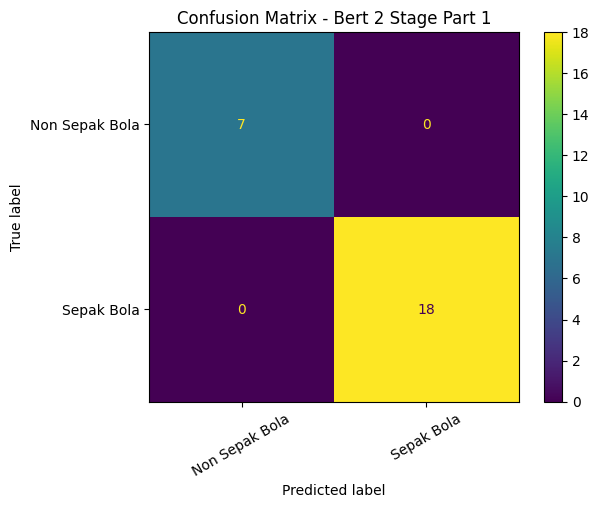

In [38]:
result2Stage('Bert 2 Stage Part 1', bert2StageLabelsPart1, bert2StagePredictionsPart1, labelModel2Stage1)

Test F1-Score: 1.0
Test Accuracy: 1.0
                precision    recall  f1-score   support

Non Sepak Bola       1.00      1.00      1.00         7
  Liga Inggris       1.00      1.00      1.00         6
   Liga Italia       1.00      1.00      1.00         4
  Liga Spanyol       1.00      1.00      1.00         5
Liga Indonesia       1.00      1.00      1.00         3

      accuracy                           1.00        25
     macro avg       1.00      1.00      1.00        25
  weighted avg       1.00      1.00      1.00        25



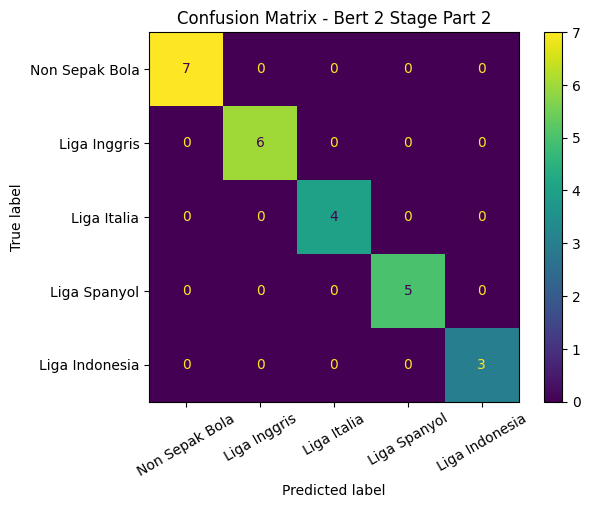

In [39]:
result2Stage('Bert 2 Stage Part 2', bert2StageLabelsPart2, bert2StagePredictionsPart2, labelModel1)

Hasil pada kedua tahap untuk model BERT sudah sangat bagus, dimana secara keseluruhan, train, val, dan test memiliki akurasi dan F1-Score sebagai 1 (Sempurna). Seperti yang dilihat pada classification report dan confusion matrix, hasil prediksi seluruh kategori sudah benar sempurna.

#### Roberta

In [40]:
roberta2StageLabelsPart1, roberta2StageLabelsPart2, roberta2StagePredictionsPart1, roberta2StagePredictionsPart2 = steps2Stage('Roberta 2 Stage', 'cahya/roberta-base-indonesian-522M', xTrain21Roberta, xVal21Roberta, xTrain22Roberta, xVal22Roberta, xTest1Roberta, 8, 2e-05, 10)

pytorch_model.bin:   0%|          | 0.00/507M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at cahya/roberta-base-indonesian-522M and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
  4%|▍         | 1/25 [00:00<00:09,  2.43it/s]

model.safetensors:   0%|          | 0.00/507M [00:00<?, ?B/s]

100%|██████████| 25/25 [00:18<00:00,  1.37it/s]


Epochs: 1
 | Train F1: 0.768 
 | Train Loss: 0.399 
 | Train Accuracy: 0.826
 | Val F1: 0.947 
 | Val Loss: 0.101 
 | Val Accuracy: 0.958 



...

100%|██████████| 18/18 [00:12<00:00,  1.40it/s]


Epochs: 9
 | Train F1: 1.0 
 | Train Loss: 0.011 
 | Train Accuracy: 1.0
 | Val F1: 0.889 
 | Val Loss: 0.079 
 | Val Accuracy: 0.941 



100%|██████████| 18/18 [00:12<00:00,  1.40it/s]


Epochs: 10
 | Train F1: 1.0 
 | Train Loss: 0.007 
 | Train Accuracy: 1.0
 | Val F1: 0.889 
 | Val Loss: 0.052 
 | Val Accuracy: 0.941 



100%|██████████| 25/25 [00:01<00:00, 18.22it/s]


Test F1-Score: 1.0
Test Accuracy: 1.0
                precision    recall  f1-score   support

Non Sepak Bola       1.00      1.00      1.00         7
    Sepak Bola       1.00      1.00      1.00        18

      accuracy                           1.00        25
     macro avg       1.00      1.00      1.00        25
  weighted avg       1.00      1.00      1.00        25



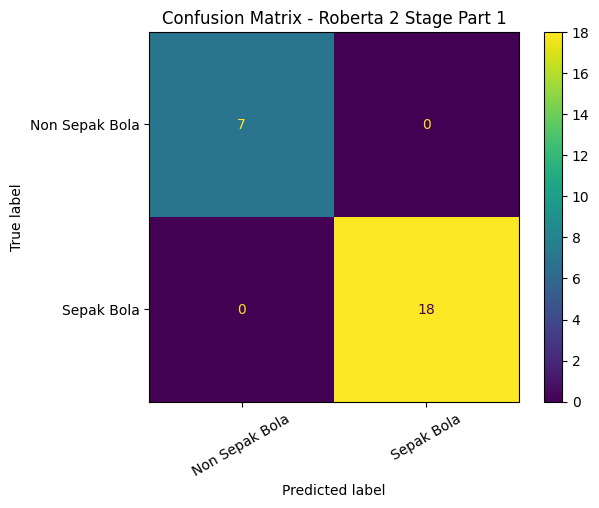

In [41]:
result2Stage('Roberta 2 Stage Part 1', roberta2StageLabelsPart1, roberta2StagePredictionsPart1, labelModel2Stage1)

Test F1-Score: 0.902
Test Accuracy: 0.92
                precision    recall  f1-score   support

Non Sepak Bola       1.00      1.00      1.00         7
  Liga Inggris       1.00      0.83      0.91         6
   Liga Italia       0.67      1.00      0.80         4
  Liga Spanyol       1.00      1.00      1.00         5
Liga Indonesia       1.00      0.67      0.80         3

      accuracy                           0.92        25
     macro avg       0.93      0.90      0.90        25
  weighted avg       0.95      0.92      0.92        25



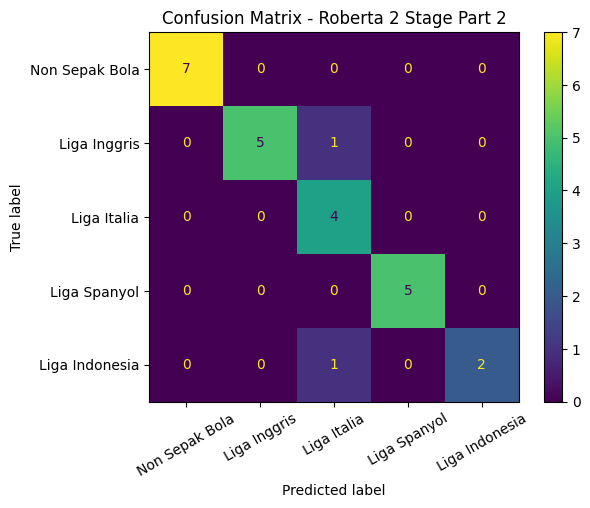

In [42]:
result2Stage('Roberta 2 Stage Part 2', roberta2StageLabelsPart2, roberta2StagePredictionsPart2, labelModel1)

Model RoBERTa juga sudah memiliki performa yang sangat bagus, akan tetapi RoBERTa masih memiliki performa dibawah BERT dimana, hasil testing masih ada 2 kategori yang kurang tepat.

## C. Evaluasi

In [35]:
resultDf = pd.DataFrame(result)
testResultDf = pd.DataFrame(testResult)

### Perbandingan 1 Stage vs 2 Stage BERT

In [36]:
colOrder = ['Bert 1 Stage', 'Bert 1 Stage Finetuned', 'Bert 2 Stage Part 1', 'Bert 2 Stage Part 2']

resultDfBert = resultDf[colOrder]
resultDfBert

,Bert 1 Stage,Bert 1 Stage Finetuned,Bert 2 Stage Part 1,Bert 2 Stage Part 2
Train F1-Score,0.202,0.985,1.0,1.0
Train Accuracy,0.277,0.99,1.0,1.0
Train Loss,1.55,0.06,0.003,0.008
Train Recall,0.198,0.98,1.0,1.0
Train Precision,0.227,0.991,1.0,1.0
Val F1-Score,0.32,1.0,1.0,1.0
Val Accuracy,0.458,1.0,1.0,1.0
Val Loss,1.527,0.068,0.001,0.003
Val Recall,0.367,1.0,1.0,1.0
Val Precision,0.386,1.0,1.0,1.0


In [37]:
testResultDfBert = testResultDf[colOrder]
testResultDfBert

,Bert 1 Stage,Bert 1 Stage Finetuned,Bert 2 Stage Part 1,Bert 2 Stage Part 2
Test F1-Score,0.147,0.960,1.0,1.0
Test Accuracy,0.240,0.960,1.0,1.0
Test Recall,0.190,0.967,1.0,1.0
Test Precision,0.137,0.960,1.0,1.0


Berdasarkan hasil BERT untuk model 1 Stage dan 2 Stage, dapat dilihat bahwa model 2 Stage memiliki performa yang lebih bagus dibandingkan model 1 stage. Dari nilai F1-Score, Accuracy, Precision, dan Recall untuk Model 2 Stage semuanya 1, sedangkan untuk model 1 Stage, model masih kurang akurat, walaupun hanya sangat kecil, yaitu hanya berbeda 1-2% untuk setiap metrik.

Sedangkan berdasarkan hasil test, Model yang langsung menebak 5 kategori juga tetap memiliki performa yang lebih jelek dibandingkan model 2 stage. Dimana untuk model 1 stage tersebut, model salah menebak  inggris sebagai italia, sehingga mengakibatkan Recall dan Precision pada inggris dan italia menurun. Sehingga, nilai Akurasi dan F1-Score juga ikut turun. 

Sehingga secara kesimpulan, model 2 Stage memiliki performa yang lebih baik. Hal ini dapat disebabkan karena model pertama hanya perlu memisahkan Sepak Bola dan Non Sepak Bola, lalu mempelajari lagi untuk memisahkan data berdasarkan Sepak Bola saja.

### Perbandingan 1 Stage vs 2 Stage RoBERTa

In [38]:
colOrder = ['Roberta 1 Stage', 'Roberta 1 Stage Finetuned', 'Roberta 2 Stage Part 1', 'Roberta 2 Stage Part 2']

resultDfRoberta = resultDf[colOrder]
resultDfRoberta

,Roberta 1 Stage,Roberta 1 Stage Finetuned,Roberta 2 Stage Part 1,Roberta 2 Stage Part 2
Train F1-Score,0.496,1.0,1.0,0.993
Train Accuracy,0.646,1.0,1.0,0.993
Train Loss,1.313,0.037,0.004,0.049
Train Recall,0.585,1.0,1.0,0.992
Train Precision,0.527,1.0,1.0,0.995
Val F1-Score,0.493,1.0,1.0,0.897
Val Accuracy,0.625,1.0,1.0,0.941
Val Loss,1.291,0.087,0.002,0.115
Val Recall,0.62,1.0,1.0,0.964
Val Precision,0.503,1.0,1.0,0.875


In [39]:
testResultDfRoberta = testResultDf[colOrder]
testResultDfRoberta

,Roberta 1 Stage,Roberta 1 Stage Finetuned,Roberta 2 Stage Part 1,Roberta 2 Stage Part 2
Test F1-Score,0.302,0.906,1.0,0.902
Test Accuracy,0.480,0.920,1.0,0.920
Test Recall,0.378,0.900,1.0,0.900
Test Precision,0.292,0.930,1.0,0.933


Secara keseluruhan, hasil model RoBERTa hampir mirip dengan BERT, tetapi untuk model RoBERTa, dari hasil training dan validasi lebih bagus untuk data 1 stage dibandingkan stage. Akan tetapi saat di tes, hasil model yang 2 stage lebih baik dari model yang 1 stage. 

Maka dapat disimpulkan bahwa performa model dengan 2 tahapan/stage memiliki performa yang lebih baik dibandingkan model 1 stage.